In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy

# Step 1: Load the Dataset

In [12]:
df = pd.read_excel(r"C:\Users\HP\Downloads\ERDS.xlsx")
print(df)
df.head()

      EmployeeID          Name  Gender  Age Department            JobRole  \
0              1  Sneha Sharma  Female   37         HR      HR Specialist   
1              2   Ravi Sharma    Male   27         HR      HR Specialist   
2              3   Vikas Singh    Male   50  Marketing     SEO Specialist   
3              4    John Patel    Male   43      Sales    Sales Executive   
4              5   John Sharma  Female   56      Sales      Sales Manager   
...          ...           ...     ...  ...        ...                ...   
4995        4996  Anjali Gupta    Male   36         IT  Software Engineer   
4996        4997    Neha Singh    Male   59         IT         IT Support   
4997        4998    Neha Singh  Female   25  Marketing     SEO Specialist   
4998        4999  Sneha Mathew    Male   57         HR      HR Specialist   
4999        5000    Ravi Mehta    Male   46      Sales    Sales Executive   

     DateOfJoining DateOfExit  PerformanceRating     ResignationReason  \
0

,EmployeeID,Name,Gender,Age,Department,JobRole,DateOfJoining,DateOfExit,PerformanceRating,ResignationReason,LastWorkingLocation
0,1,Sneha Sharma,Female,37,HR,HR Specialist,2007-04-20,2023-06-23,5,Better Opportunity,Chennai
1,2,Ravi Sharma,Male,27,HR,HR Specialist,2016-05-02,2024-01-31,1,Work-life Balance,Hyderabad
2,3,Vikas Singh,Male,50,Marketing,SEO Specialist,2005-02-23,2023-03-02,2,Retirement,Bangalore
3,4,John Patel,Male,43,Sales,Sales Executive,2013-07-10,2015-08-10,3,Low Job Satisfaction,Chennai
4,5,John Sharma,Female,56,Sales,Sales Manager,2006-10-08,2020-02-24,3,Work-life Balance,Kolkata


# Step 2: Data Preprocessing

In [21]:

df['DateOfJoining'] = pd.to_datetime(df['DateOfJoining'])
df['DateOfExit'] = pd.to_datetime(df['DateOfExit'])

# Tenure Calculation
df['TenureYears'] = (df['DateOfExit'] - df['DateOfJoining']).dt.days / 365.25

# Year of Exit
df['YearOfExit'] = df['DateOfExit'].dt.year

df


,EmployeeID,Name,Gender,Age,Department,JobRole,DateOfJoining,DateOfExit,PerformanceRating,ResignationReason,LastWorkingLocation,TenureYears,YearOfExit
0,1,Sneha Sharma,Female,37,HR,HR Specialist,2007-04-20,2023-06-23,5,Better Opportunity,Chennai,16.175222,2023
1,2,Ravi Sharma,Male,27,HR,HR Specialist,2016-05-02,2024-01-31,1,Work-life Balance,Hyderabad,7.748118,2024
2,3,Vikas Singh,Male,50,Marketing,SEO Specialist,2005-02-23,2023-03-02,2,Retirement,Bangalore,18.017796,2023
3,4,John Patel,Male,43,Sales,Sales Executive,2013-07-10,2015-08-10,3,Low Job Satisfaction,Chennai,2.083504,2015
4,5,John Sharma,Female,56,Sales,Sales Manager,2006-10-08,2020-02-24,3,Work-life Balance,Kolkata,13.379877,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,Anjali Gupta,Male,36,IT,Software Engineer,2008-08-18,2023-03-07,3,Retirement,Mumbai,14.548939,2023
4996,4997,Neha Singh,Male,59,IT,IT Support,2020-08-14,2024-07-12,3,Retirement,Pune,3.909651,2024
4997,4998,Neha Singh,Female,25,Marketing,SEO Specialist,2015-04-13,2022-10-13,3,Personal Reasons,Delhi,7.501711,2022
4998,4999,Sneha Mathew,Male,57,HR,HR Specialist,2019-05-26,2023-01-02,1,Work-life Balance,Mumbai,3.605749,2023


# Step 3: Summary Statistics

In [38]:
print("Total Resignations :",df.shape[0])
print("\nAverage Age at Resignations :",df['Age'].mean())
print("\nAverage Tenure (Years) :",df['TenureYears'].mean())
print("\nResignations by Genders :\n",df['Gender'].value_counts())
print("\nTop Resignation Reason :\n",df['ResignationReason'].value_counts())

Total Resignations : 5000

Average Age at Resignations : 40.8364

Average Tenure (Years) : 6.466508966461327

Resignations by Genders :
 Gender
Male      2520
Female    2480
Name: count, dtype: int64

Top Resignation Reason :
 ResignationReason
Better Opportunity      1017
Retirement              1004
Work-life Balance       1000
Low Job Satisfaction     997
Personal Reasons         982
Name: count, dtype: int64


In [28]:
df.columns

Index(['EmployeeID', 'Name', 'Gender', 'Age', 'Department', 'JobRole',
       'DateOfJoining', 'DateOfExit', 'PerformanceRating', 'ResignationReason',
       'LastWorkingLocation', 'TenureYears', 'YearOfExit'],
      dtype='str')

# Step 4: Department-Wise Resignations

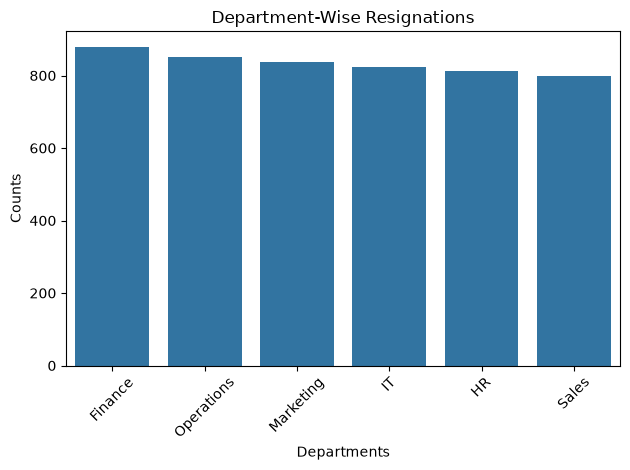

In [49]:
dept_count = df["Department"].value_counts()

sns.barplot(x=dept_count.index,y=dept_count.values,legend=True)
plt.xticks(rotation=45)
plt.title("Department-Wise Resignations")
plt.xlabel("Departments")
plt.ylabel("Counts")
plt.tight_layout()
plt.show()

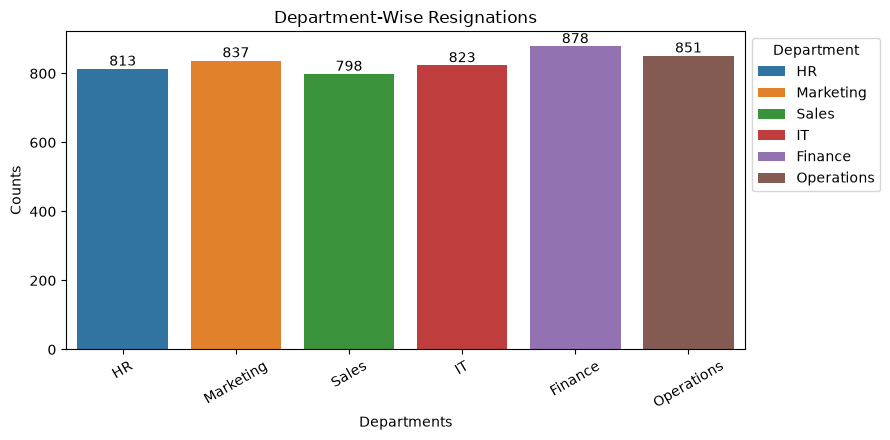

In [86]:
plt.figure(figsize=(9,4.5))
ax = sns.countplot(x="Department",data=df,hue="Department",legend=True)

# Show counts on top of bars
for container in ax.containers :
    ax.bar_label(container,padding=0)
plt.xticks(rotation=30)
plt.title("Department-Wise Resignations")
plt.xlabel("Departments")
plt.ylabel("Counts")

# Legend outside the chart
plt.legend(title="Department",bbox_to_anchor=(1,1),loc="upper left")
plt.tight_layout()
plt.show()

# Step 5: Resignation Trends Over Years

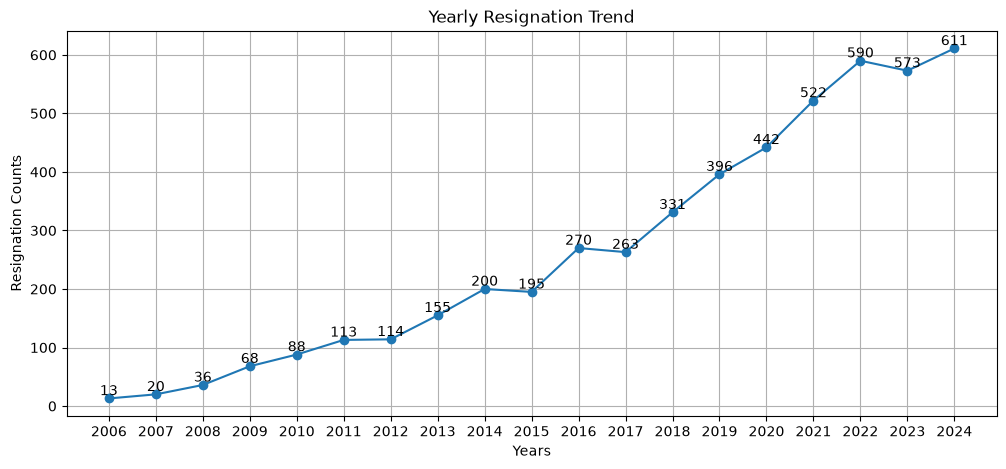

In [106]:
plt.figure(figsize=(12,5))
yearly_counts = df["YearOfExit"].value_counts().sort_index()
yearly_counts.plot(kind="line",marker="o")

# Shows counts on top of points
for x, y in yearly_counts.items():
    plt.text(x,y,y, ha="center", va="bottom")

plt.xticks(yearly_counts.index)
plt.title("Yearly Resignation Trend")
plt.xlabel("Years")
plt.ylabel("Resignation Counts")
plt.grid(True)
plt.show()


# Step 6: Reason vs Department Heatmap

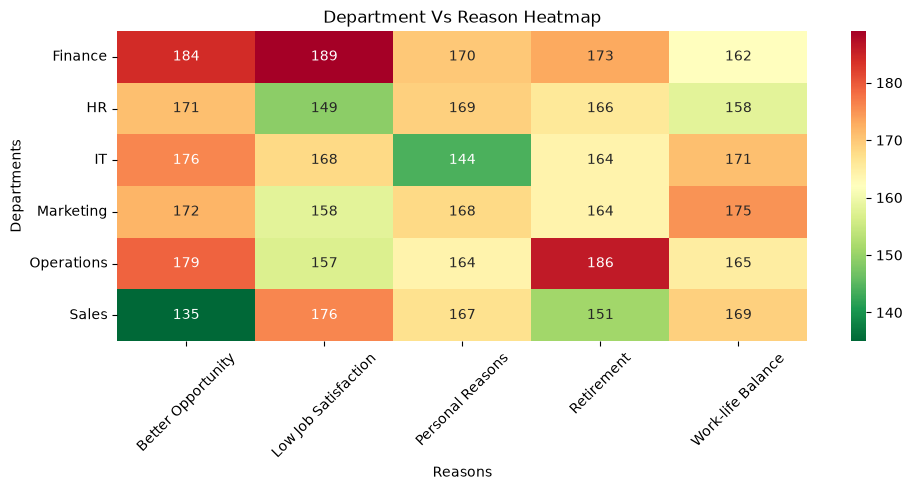

In [131]:
plt.figure(figsize=(10,5))
pivot = pd.pivot_table(df,values="EmployeeID",index="Department",columns="ResignationReason",
                       aggfunc="count",fill_value=0)
sns.heatmap(pivot,annot=True,fmt="d",cmap="RdYlGn_r")
plt.xticks(rotation=45)
plt.title("Department Vs Reason Heatmap")
plt.ylabel("Departments")
plt.xlabel("Reasons")
plt.tight_layout()
plt.show()

# Step 7: Age vs Tenure Scatter Plot

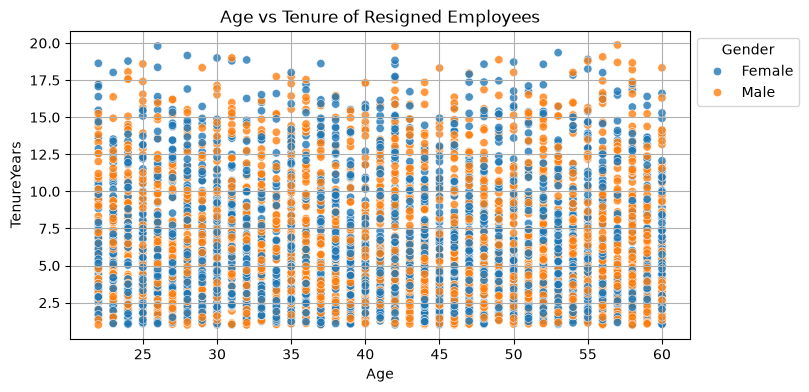

In [146]:
plt.figure(figsize=(8,4))
sns.scatterplot(data=df,x="Age",y="TenureYears",hue="Gender",alpha=0.8)
plt.legend(title="Gender",bbox_to_anchor=(1,1),loc="upper left")

plt.title("Age vs Tenure of Resigned Employees")
plt.grid(True)
plt.show()

<h3>Final Insights & Recommendations</h3>
1.Departments with the most resignations should be investigated for work culture, leadership, or growth path.<br>
2.High performers (ratings 4–5) resigning frequently could indicate Better job offers or unmet expectations.<br>3.
Frequent resignations due to better opportunities suggest that salaries may not be competitive and that a salary structure update may be required.

In [147]:
summary = { "Total Resignations": df.shape[0],
            "Average Age": df['Age'].mean(), 
            "Average Tenure": df['TenureYears'].mean(), } 
summary_df = pd.DataFrame([summary]) 
summary_df.to_excel("Resignation_Summary_Report.xlsx", index=False)